![Henry Logo](https://www.soyhenry.com/_next/static/media/HenryLogo.bb57fd6f.svg)



# M3L1 E00 - Pipeline Mock vs Agente ReAct

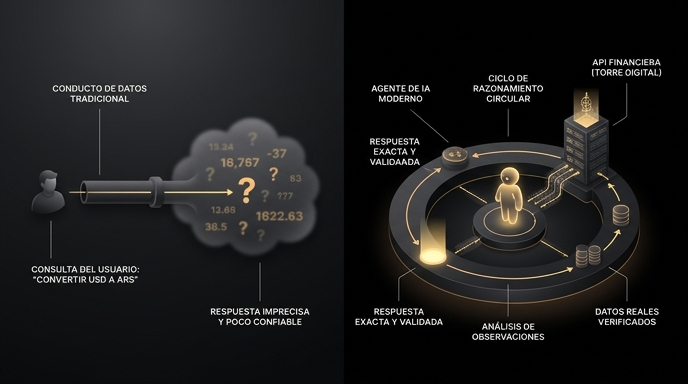


## Importante antes de empezar

Este notebook **no usa una API real de IA**.

La respuesta del supuesto LLM esta simulada con `llm_pipeline_mock()` para que la practica se enfoque en arquitectura.

La tool de datos, en cambio, **si consulta una API real**: DolarAPI.

Entonces, aca no estamos validando si una IA responde bien. Estamos validando esta diferencia:

> Pipeline: responde sin consultar datos actuales.  
> Agente: usa una tool real, observa el resultado y responde con ese dato.

## Objetivo del ejercicio

Completar un agente ReAct minimo que responda cuanto son 100 USD en pesos argentinos usando una consulta real a DolarAPI.

## Que se valida

Los checks validan:

- que la tool de cotizacion devuelve un contrato estable;
- que la conversion calcula bien;
- que el agente no devuelve `None`;
- que la respuesta final incluye monto, resultado, fecha y fuente.


## Definiciones usadas en este notebook

| Concepto | Definicion simple | Como aparece en este notebook |
|---|---|---|
| LLM Pipeline | Flujo fijo que recibe input y devuelve texto. | `llm_pipeline_mock()` responde sin usar tools. |
| AI Agent | Sistema que puede decidir acciones y observar resultados. | `agente_react()` llama tools antes de responder. |
| Tool | Funcion que obtiene datos o ejecuta una accion. | `obtener_dolar_blue()` y `convertir_usd_a_pesos()`. |
| Observation | Resultado que devuelve una tool. | La cotizacion del dolar y el total convertido. |
| Grounding | Respuesta basada en datos observados. | La respuesta final cita cotizacion, fecha y fuente. |
| Trace | Registro de pasos ejecutados. | Los prints muestran Thought, Action y Observation. |
| ReAct | Reasoning + Acting. | Pensar -> actuar -> observar -> responder. |

En este ejercicio dejamos fuera `state` complejo y `max_steps` para mantener el foco en la diferencia entre pipeline y agente.


## Paso 1 - Pipeline LLM simulado

La respuesta sigue siendo un mock: no consulta datos actuales.


In [1]:
PREGUNTA = "Cuanto son 100 USD en pesos argentinos hoy?"


def llm_pipeline_mock(pregunta: str) -> str:
    """Simula una respuesta de IA sin tools.

    En una clase real podriamos reemplazar esta funcion por una llamada a una API
    de IA, pero para este ejercicio queremos enfocarnos en arquitectura de agentes.
    """
    print("[Pipeline] Pregunta del usuario:")
    print(f"[Pipeline] {pregunta}")
    print("[Pipeline] Respondo sin consultar datos actuales.")
    return "100 USD son aproximadamente 100.000 pesos argentinos."


respuesta_pipeline = llm_pipeline_mock(PREGUNTA)
print(f"[Respuesta pipeline] {respuesta_pipeline}")
print("[Problema] Esta respuesta puede estar desactualizada porque no uso una tool.")


[Pipeline] Pregunta del usuario:
[Pipeline] Cuanto son 100 USD en pesos argentinos hoy?
[Pipeline] Respondo sin consultar datos actuales.
[Respuesta pipeline] 100 USD son aproximadamente 100.000 pesos argentinos.
[Problema] Esta respuesta puede estar desactualizada porque no uso una tool.


## Paso 2 - API real de cotizacion

Vamos a usar DolarAPI:

```text
https://dolarapi.com/v1/dolares/blue
```

La API devuelve un JSON con datos como:

```python
{
    "compra": 1000,
    "venta": 1020,
    "fechaActualizacion": "..."
}
```

La tool va a consultar esa URL y devolver un contrato simple para el agente.


In [1]:
import requests

DOLAR_API_URL = "https://dolarapi.com/v1/dolares/blue"


## Solucion Paso 3 - Tool de cotizacion

La tool normaliza nombres y tipos para que el agente reciba un contrato simple.


In [2]:
def obtener_dolar_blue() -> dict:
    """Tool: consulta DolarAPI y normaliza la cotizacion del dolar blue."""
    response = requests.get(DOLAR_API_URL, timeout=10)
    response.raise_for_status()
    payload = response.json()
    print(f"payload DolarAPI -> {payload}")

    return {
        "compra": float(payload["compra"]),
        "venta": float(payload["venta"]),
        "fecha": payload["fechaActualizacion"],
        "source": "DolarAPI",
    }


## Solucion Paso 4 - Tool de calculo

La tool valida inputs y calcula de forma deterministica.


In [ ]:
def convertir_usd_a_pesos(monto_usd: float, cotizacion: float) -> float:
    """Tool: convierte USD a pesos usando una cotizacion."""
    if monto_usd <= 0 or cotizacion <= 0:
        raise ValueError("monto_usd y cotizacion deben ser mayores a 0")
    return round(monto_usd * cotizacion, 2)


## Paso 5 - Debug visual de tools

Ejecuta esta celda para ver claramente que devuelve cada funcion.

No usamos asserts aca: usamos prints para seguir el flujo de datos.


In [ ]:
print(f"DOLAR_API_URL = {DOLAR_API_URL}")

cotizacion_demo = obtener_dolar_blue()
print(f"obtener_dolar_blue() -> {cotizacion_demo}")

venta_demo = cotizacion_demo["venta"]
print(f"cotizacion_demo['venta'] -> {venta_demo}")

conversion_demo = convertir_usd_a_pesos(100, venta_demo)
print(f"convertir_usd_a_pesos(100, {venta_demo}) -> {conversion_demo}")


## Solucion Paso 6 - Agente ReAct

La solucion muestra explicitamente Thought, Action, Observation y Final Answer.


In [ ]:
def agente_react(pregunta: str) -> str:
    print("[Agente] Pregunta del usuario:")
    print(f"[Agente] {pregunta}")

    print("[Thought] Necesito una cotizacion antes de responder.")
    print("[Action] obtener_dolar_blue()")
    cotizacion = obtener_dolar_blue()
    print(f"[Observation] {cotizacion}")

    print("[Thought] Uso la cotizacion de venta para convertir 100 USD.")
    print("[Action] convertir_usd_a_pesos(100, venta)")
    venta = cotizacion["venta"]
    total_pesos = convertir_usd_a_pesos(100, venta)
    print(f"[Observation] total_pesos={total_pesos}")

    return (
        f"100 USD al dolar blue venta de {venta} ARS "
        f"son {total_pesos} pesos argentinos. "
        f"Fecha: {cotizacion['fecha']}. Fuente: {cotizacion['source']}."
    )


## Paso 7 - Debug final del agente

Ejecuta el agente completo y mira el trace.

La salida debe mostrar Thought, Action, Observation y la respuesta final.


In [ ]:
respuesta_agente = agente_react(PREGUNTA)
print(f"agente_react(PREGUNTA) -> {respuesta_agente}")


## Cierre - Que deberia quedar claro

Este ejercicio no busca mostrar una API de IA.

Busca mostrar esta diferencia:

| Pipeline mock | Agente ReAct |
|---|---|
| Responde texto directo. | Usa una tool real antes de responder. |
| No observa datos actuales. | Observa la cotizacion desde DolarAPI. |
| No tiene grounding. | Incluye fecha y fuente. |
| No deja trace de acciones. | Muestra Thought, Action y Observation. |

Cuando quieras conectar esto con una API real de IA, `llm_pipeline_mock()` podria reemplazarse por una llamada a OpenAI, Gemini, Claude, etc.

Pero el patron que estamos aprendiendo no depende de eso: depende de tools, observaciones y respuesta grounded.
